# Corporate Actions: Adjusting for Splits and Dividends

**Docker image**: `ml4t`

**Purpose**: Demonstrate why unadjusted price series mis-represent returns
across stock splits and cash dividends, derive the industry-standard backward
adjustment, and validate the `ml4t.data.adjustments.apply_corporate_actions`
implementation against the pre-adjusted Quandl WIKI series.

**Learning objectives**:

- Identify how splits and dividends break raw price continuity.
- Apply the backward-adjustment formula for splits and dividends.
- Use `apply_corporate_actions` to produce an adjusted OHLCV panel.
- Validate adjusted prices against a trusted reference series.
- Pick the right price representation for a given strategy horizon.

**Book reference**: §2.3 ("A Due Diligence Framework for Data Sourcing" —
corporate-action handling) and §2.2 (Equities).

**Prerequisites**: Wiki Prices US-equities parquet on disk
(`load_us_equities` resolves it via `ML4T_DATA_PATH`); `ml4t-data` library
installed.

In [1]:
"""Corporate Actions — Adjusting for splits and dividends in historical price series."""

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from ml4t.data.adjustments import apply_corporate_actions

from data import load_us_equities

.venv/lib/python3.14/site-packages/kaleido/scopes/plotly.py:32: DeprecationWarning: 
Use of plotly.io.kaleido.scope.default_format is deprecated and support will be removed after September 2025.
Please use plotly.io.defaults.default_format instead.

  self.default_format = "png"
.venv/lib/python3.14/site-packages/kaleido/scopes/plotly.py:33: DeprecationWarning: 
Use of plotly.io.kaleido.scope.default_width is deprecated and support will be removed after September 2025.
Please use plotly.io.defaults.default_width instead.

  self.default_width = 700
.venv/lib/python3.14/site-packages/kaleido/scopes/plotly.py:34: DeprecationWarning: 
Use of plotly.io.kaleido.scope.default_height is deprecated and support will be removed after September 2025.
Please use plotly.io.defaults.default_height instead.

  self.default_height = 500
.venv/lib/python3.14/site-packages/kaleido/scopes/plotly.py:35: DeprecationWarning: 
Use of plotly.io.kaleido.scope.default_scale is deprecated and support will be rem

In [2]:
# Production defaults — Papermill injects overrides for CI

## 1. Why Corporate Actions Matter

Corporate actions break the continuity of price series. Without proper
adjustments:

- **Stock splits** appear as massive price drops (e.g., a 2:1 split looks like
  a $-50\%$ return).
- **Dividends** cause ex-date price drops that distort return calculations.
- **ML features** computed on unadjusted prices are therefore systematically
  wrong.

### Types of corporate actions

| Type | Description | Effect on price | Effect on shares |
|------|-------------|-----------------|------------------|
| Stock split        | e.g., 2:1 split           | Halved          | Doubled    |
| Reverse split      | e.g., 1:4 split           | Quadrupled      | Quartered  |
| Cash dividend      | Payment to shareholders   | Drops by amount | Unchanged  |
| Stock dividend     | Additional shares issued  | Drops pro rata  | Increased  |

## 2. Load the Wiki Prices Panel

The Quandl WIKI dataset is well-suited for studying corporate actions because
it ships raw prices alongside the original split and dividend events plus a
pre-calculated adjusted series — so the adjusted column doubles as a
reference to validate against.

In [3]:
raw_wiki = load_us_equities()
print(f"Wiki Prices loaded: {len(raw_wiki):,} rows")

Wiki Prices loaded: 15,389,314 rows


Apple is a clean illustrative example: four splits and 54 cash dividends
across 1980–2018.

In [4]:
dividend_col = "ex_dividend" if "ex_dividend" in raw_wiki.columns else "ex-dividend"
aapl = raw_wiki.filter(pl.col("symbol") == "AAPL").sort("timestamp")

print(f"AAPL records: {len(aapl):,}  ({aapl['timestamp'].min()} to {aapl['timestamp'].max()})")

AAPL records: 9,400  (1980-12-12 to 2018-03-27)


Stock splits in the AAPL history.

In [5]:
splits = aapl.filter(pl.col("split_ratio") != 1.0)
splits.select(["timestamp", "close", "split_ratio", "adj_close"])

timestamp,close,split_ratio,adj_close
date,f64,f64,f64
1987-06-16,41.5,2.0,1.220334
2000-06-21,55.63,2.0,3.574615
2005-02-28,44.86,2.0,5.765135
2014-06-09,93.7,7.0,88.193435


First ten of 54 cash dividends.

In [6]:
dividends = aapl.filter(pl.col(dividend_col) > 0)
dividends.select(["timestamp", "close", dividend_col, "adj_close"]).head(10)

timestamp,close,ex-dividend,adj_close
date,f64,f64,f64
1987-11-17,35.0,0.08,1.031549
1988-02-12,41.0,0.08,1.210744
1988-05-16,41.25,0.08,1.220489
1988-08-15,41.25,0.08,1.222856
1988-11-21,36.63,0.1,1.088861
1989-02-17,36.75,0.1,1.095401
1989-05-22,46.0,0.1,1.374094
1989-08-21,42.25,0.1,1.265063
1989-11-17,44.75,0.11,1.343212


## 3. Three Ways to Represent Prices

1. **Raw (unadjusted)** — exactly as traded on the exchange. Best for
   order-execution simulation; returns are distorted at action dates.
2. **Split-adjusted** — adjusts for stock splits only. Reasonable for
   short-horizon trading where dividends are negligible.
3. **Total-return (split + dividend) adjusted** — the standard for ML
   features, factor research, and long-horizon backtests.

The choice of representation determines whether returns are economically
meaningful or dominated by accounting artifacts.

## 4. Raw vs Adjusted Cumulative Return

Compute cumulative returns from both raw and adjusted close prices and plot
them on a log scale; each split shows up as a discontinuity in the raw
series.

In [7]:
dates_arr = aapl["timestamp"].to_numpy()
raw_close = aapl["close"].to_numpy()
adj_close = aapl["adj_close"].to_numpy()
split_dates = splits["timestamp"].to_numpy()
split_ratios = splits["split_ratio"].to_numpy()

raw_returns = np.diff(raw_close) / raw_close[:-1]
adj_returns = np.diff(adj_close) / adj_close[:-1]
raw_cumret = np.cumprod(1 + raw_returns)
adj_cumret = np.cumprod(1 + adj_returns)

/tmp/ipykernel_1782518/80055116.py:48: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


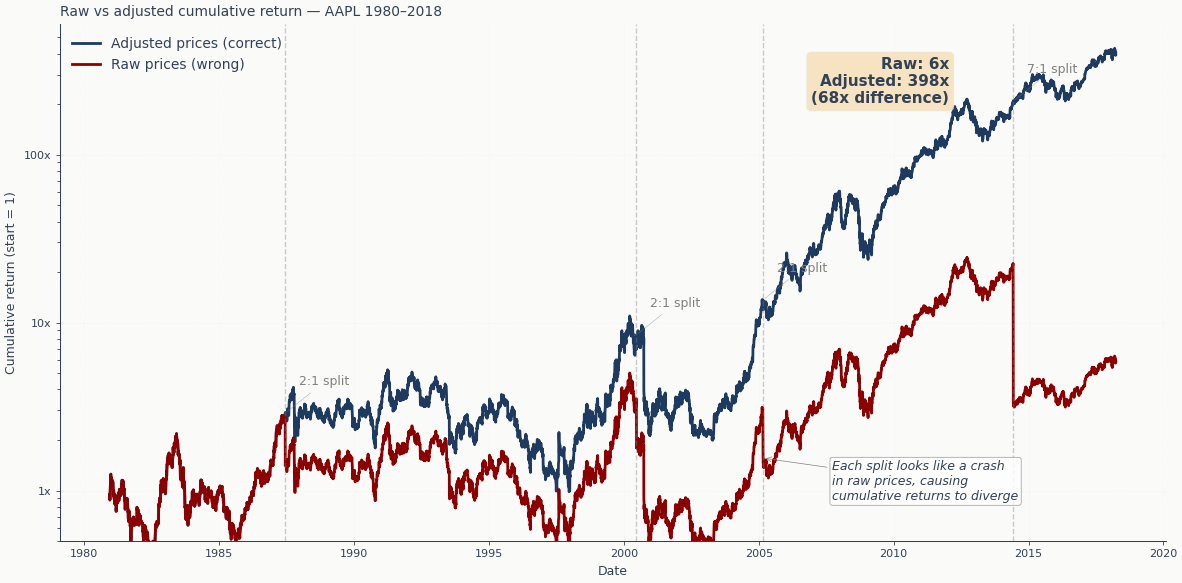

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(dates_arr[1:], adj_cumret, label="Adjusted prices (correct)", color="#1E3A5F", linewidth=2)
ax.plot(dates_arr[1:], raw_cumret, label="Raw prices (wrong)", color="#8B0000", linewidth=2)

for d, ratio in zip(split_dates, split_ratios, strict=False):
    ax.axvline(d, color="gray", linestyle="--", alpha=0.4, linewidth=1)
    idx = np.searchsorted(dates_arr[1:], d)
    if idx < len(adj_cumret):
        ax.annotate(
            f"{int(ratio)}:1 split",
            xy=(d, adj_cumret[idx]),
            xytext=(10, 20),
            textcoords="offset points",
            fontsize=9,
            color="gray",
            arrowprops=dict(arrowstyle="-", color="gray", alpha=0.5),
        )

ax.annotate(
    f"Raw: {raw_cumret[-1]:.0f}x\nAdjusted: {adj_cumret[-1]:.0f}x\n({adj_cumret[-1] / raw_cumret[-1]:.0f}x difference)",
    xy=(dates_arr[-1], (raw_cumret[-1] + adj_cumret[-1]) / 2),
    xytext=(-120, 0),
    textcoords="offset points",
    fontsize=11,
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="wheat", alpha=0.8),
    ha="right",
)
ax.annotate(
    "Each split looks like a crash\nin raw prices, causing\ncumulative returns to diverge",
    xy=(split_dates[2], raw_cumret[np.searchsorted(dates_arr[1:], split_dates[2])]),
    xytext=(50, -30),
    textcoords="offset points",
    fontsize=9,
    style="italic",
    bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8, edgecolor="gray"),
    arrowprops=dict(arrowstyle="->", color="gray"),
)

ax.set_ylabel("Cumulative return (start = 1)")
ax.set_xlabel("Date")
ax.set_title("Raw vs adjusted cumulative return — AAPL 1980–2018")
ax.legend(loc="upper left", fontsize=10)
ax.set_yscale("log")
ax.set_ylim(0.5, adj_cumret[-1] * 1.5)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}x" if x >= 1 else f"{x:.1f}x"))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# Persist Figure 2.3 artifact for book script (Hard Rule 15).
import polars as _pl

from utils.paths import get_chapter_dir as _get_chapter_dir

_ARTIFACTS_DIR = _get_chapter_dir(2) / "output" / "book_figure_artifacts"
_ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
_pl.DataFrame(
    {
        "timestamp": dates_arr[1:],
        "adj_cumret": adj_cumret,
        "raw_cumret": raw_cumret,
    }
).write_parquet(_ARTIFACTS_DIR / "figure_2_3_corporate_actions_curves.parquet")
_pl.DataFrame(
    {
        "split_date": split_dates,
        "split_ratio": split_ratios,
    }
).write_parquet(_ARTIFACTS_DIR / "figure_2_3_corporate_actions_splits.parquet")
print(
    f"Persisted figure_2_3_corporate_actions: {len(adj_cumret)} dates, "
    f"{len(split_dates)} splits, final raw={raw_cumret[-1]:.1f}x adj={adj_cumret[-1]:.1f}x"
)

Persisted figure_2_3_corporate_actions: 9399 dates, 4 splits, final raw=5.9x adj=398.2x


Quantify the divergence: a buy-and-hold of AAPL since 1980 returned roughly
$400\times$ on a total-return basis but only $\sim 6\times$ on raw prices —
the entire dividend stream and the share-count effect of the four splits are
missing from the raw series.

In [10]:
print(f"Final cumulative return — raw prices:      {raw_cumret[-1]:.1f}x")
print(f"Final cumulative return — adjusted prices: {adj_cumret[-1]:.1f}x")
print(f"Ratio: {adj_cumret[-1] / raw_cumret[-1]:.0f}x difference")
print(
    f"Raw prices understate the cumulative return by {(adj_cumret[-1] / raw_cumret[-1] - 1) * 100:.0f}%"
)

Final cumulative return — raw prices:      5.9x
Final cumulative return — adjusted prices: 398.2x
Ratio: 68x difference
Raw prices understate the cumulative return by 6701%


## 5. The `apply_corporate_actions` API

The `apply_corporate_actions` function in `ml4t.data.adjustments` implements
the backward-adjustment methodology shared by Quandl and most major data
vendors. The function signature documents the convention it expects.

In [11]:
help(apply_corporate_actions)

Help on function apply_corporate_actions in module ml4t.data.adjustments.core:

apply_corporate_actions(
    prices: pl.DataFrame,
    split_col: str = 'split_ratio',
    dividend_col: str = 'ex-dividend',
    price_cols: list[str] | None = None,
    volume_col: str | None = 'volume'
) -> pl.DataFrame
    Apply both split and dividend adjustments to create fully adjusted prices.

    Uses the industry-standard backward-adjustment methodology where each day's
    adjusted price is calculated from the next day's adjusted price and corporate
    actions. This matches the approach used by Quandl, Yahoo Finance, and other
    major data providers.

    Args:
        prices: DataFrame with date-sorted prices and corporate action data
        split_col: Column with split ratios (default: 'split_ratio')
        dividend_col: Column with dividend amounts (default: 'ex-dividend')
        price_cols: Price columns to adjust (default: ['open', 'high', 'low', 'close'])
        volume_col: Volume co

Apply the adjustment to AAPL. The function expects a `date` column and
returns the input frame plus `adj_*` columns; we round-trip through the
canonical `timestamp` schema.

In [12]:
adjusted = apply_corporate_actions(
    aapl.rename({"timestamp": "date"}),
    split_col="split_ratio",
    dividend_col=dividend_col,
    price_cols=["open", "high", "low", "close"],
    volume_col="volume",
).rename({"date": "timestamp"})

print("Adjusted columns:", [c for c in adjusted.columns if c.startswith("adj_")])

Adjusted columns: ['adj_open', 'adj_high', 'adj_low', 'adj_close', 'adj_volume']


Side-by-side comparison at the IPO, three split dates, and the dataset end.
`our_adj_close` comes from this notebook's invocation of
`apply_corporate_actions`; `quandl_adj_close` is the pre-computed adjusted
series shipped with the dataset.

In [13]:
from datetime import date as _date

example_dates = [
    _date(1980, 12, 12),
    _date(1987, 6, 16),
    _date(2000, 6, 21),
    _date(2014, 6, 9),
    _date(2018, 3, 27),
]

comparison = (
    adjusted.filter(pl.col("timestamp").is_in(example_dates))
    .select(
        pl.col("timestamp"),
        pl.col("close").alias("raw_close"),
        pl.col("adj_close").alias("our_adj_close"),
        pl.col("split_ratio"),
    )
    .join(
        aapl.select(
            pl.col("timestamp"),
            pl.col("adj_close").alias("quandl_adj_close"),
        ),
        on="timestamp",
    )
    .sort("timestamp")
)

comparison

timestamp,raw_close,our_adj_close,split_ratio,quandl_adj_close
date,f64,f64,f64,f64
1980-12-12,28.75,0.422811,1.0,0.422706
1987-06-16,41.5,1.220637,2.0,1.220334
2000-06-21,55.63,3.574846,2.0,3.574615
2014-06-09,93.7,88.194529,7.0,88.193435
2018-03-27,168.34,168.34,1.0,168.34


## 6. Validation Against Quandl's Reference

Compare every row of the locally-computed adjusted close to Quandl's
pre-calculated value. With ~9,400 iterative backward updates, small
floating-point error accumulates; the published convention tolerates a
relative difference of about $5 \times 10^{-4}$.

In [14]:
our_adj = adjusted["adj_close"].to_numpy()
quandl_adj = aapl["adj_close"].to_numpy()
dates = adjusted["timestamp"].to_numpy()

absolute_diff = np.abs(our_adj - quandl_adj)
relative_diff = absolute_diff / quandl_adj * 100
tolerance_pct = 0.05  # 0.05 %

print(f"Total comparisons:        {len(our_adj):,}")
print(f"Max absolute difference:  ${absolute_diff.max():.6f}")
print(f"Max relative difference:  {relative_diff.max():.4f}%")
print(f"Mean relative difference: {relative_diff.mean():.6f}%")
print(f"Median relative difference: {np.median(relative_diff):.6f}%")
print()
if np.allclose(our_adj, quandl_adj, rtol=tolerance_pct / 100):
    print(f"VALIDATION PASSED — within {tolerance_pct:.4f}% relative tolerance.")
else:
    n_out = int((relative_diff > tolerance_pct).sum())
    print(f"VALIDATION FAILED — {n_out} rows outside {tolerance_pct:.4f}% tolerance.")

Total comparisons:        9,400
Max absolute difference:  $0.020852
Max relative difference:  0.0249%
Mean relative difference: 0.010832%
Median relative difference: 0.006457%

VALIDATION PASSED — within 0.0500% relative tolerance.


Visual check — the two series overlay on the log-scale price chart, and the
rolling relative difference stays below the tolerance line.

/tmp/ipykernel_1782518/373669185.py:26: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


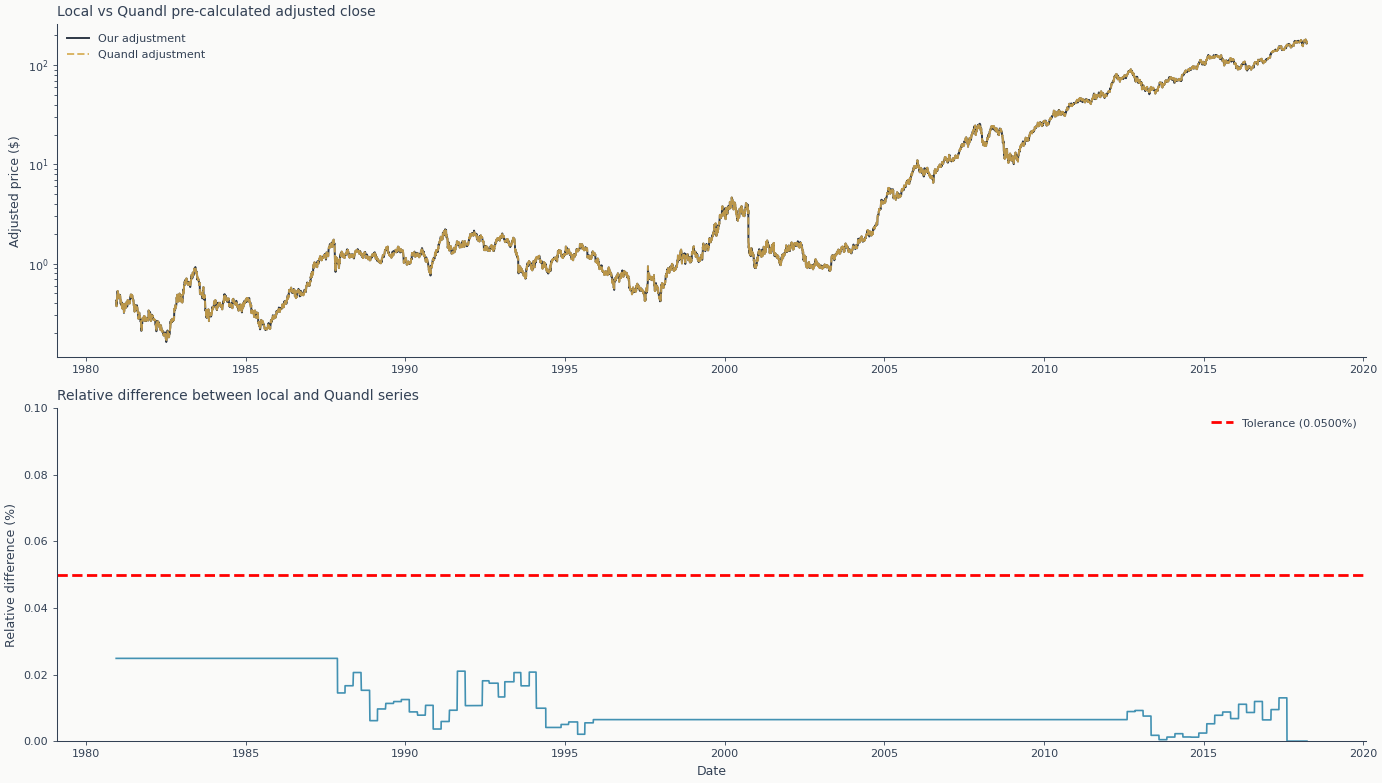

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

ax1 = axes[0]
ax1.plot(dates, our_adj, label="Our adjustment", alpha=0.85)
ax1.plot(dates, quandl_adj, label="Quandl adjustment", alpha=0.85, linestyle="--")
ax1.set_ylabel("Adjusted price ($)")
ax1.set_title("Local vs Quandl pre-calculated adjusted close")
ax1.set_yscale("log")
ax1.legend()

ax2 = axes[1]
ax2.plot(dates, relative_diff, color="#2E86AB", linewidth=1.2, alpha=0.9)
ax2.axhline(
    tolerance_pct,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Tolerance ({tolerance_pct:.4f}%)",
)
ax2.set_ylabel("Relative difference (%)")
ax2.set_xlabel("Date")
ax2.set_title("Relative difference between local and Quandl series")
ax2.set_ylim(0, max(relative_diff.max() * 1.1, tolerance_pct * 2))
ax2.legend()

plt.tight_layout()
plt.show()

## 7. The Adjustment Formulas

The industry-standard method is **backward adjustment**: start at the most
recent date with `factor = 1` and walk backwards in time, multiplying the
factor at each corporate action so future prices remain unchanged and
historical prices are scaled down.

**Split adjustment.** On the day before a stock split with ratio $R$, all
prior prices must be divided by $R$:

$$\text{factor}_{t-1} = \text{factor}_{t} \times \frac{1}{R_t}.$$

**Dividend adjustment.** On ex-dividend date $t$, with closing price
$P_{t-1}$ on the day before and dividend amount $D_t$, the multiplier for
pre-ex-date prices is

$$m_t = \frac{P_{t-1} - D_t}{P_{t-1}} = 1 - \frac{D_t}{P_{t-1}}, \qquad
  \text{factor}_{t-1} = \text{factor}_{t} \times m_t.$$

**Combined.** For any date $d$ the adjusted price is

$$P^{\text{adj}}_d = P^{\text{raw}}_d \cdot \text{factor}_d.$$

This backward-looking rule guarantees that returns computed on the adjusted
series equal the total-return of holding the stock with dividends reinvested.

### Numeric demonstration — split

In [16]:
def demonstrate_split_adjustment(
    price_before: float = 270.0, shares_before: int = 100, ratio: float = 3.0
) -> None:
    """Print a worked example of backward split adjustment."""
    value_before = price_before * shares_before
    price_after = price_before / ratio
    shares_after = shares_before * ratio
    value_after = price_after * shares_after

    print(
        f"Before {int(ratio)}:1 split — price ${price_before:.2f}, shares {shares_before:d}, value ${value_before:,.2f}"
    )
    print(
        f"After  {int(ratio)}:1 split — price ${price_after:.2f}, shares {int(shares_after):d}, value ${value_after:,.2f}"
    )
    print(
        f"Backward-adjusted historical price: ${price_before:.2f} / {ratio:.0f} = ${price_before / ratio:.2f}"
    )
    print(f"Adjusted series is now continuous: ${price_before / ratio:.2f} -> ${price_after:.2f}")

In [17]:
demonstrate_split_adjustment()

Before 3:1 split — price $270.00, shares 100, value $27,000.00
After  3:1 split — price $90.00, shares 300, value $27,000.00
Backward-adjusted historical price: $270.00 / 3 = $90.00
Adjusted series is now continuous: $90.00 -> $90.00


### Numeric demonstration — dividend

In [18]:
def demonstrate_dividend_adjustment(price_before_ex: float = 100.0, dividend: float = 5.0) -> None:
    """Print a worked example of backward dividend adjustment."""
    price_on_ex = price_before_ex - dividend
    raw_return = (price_on_ex - price_before_ex) / price_before_ex
    multiplier = price_on_ex / price_before_ex
    adjusted_before = price_before_ex * multiplier
    adj_return = (price_on_ex - adjusted_before) / adjusted_before

    print(
        f"Day before ex: ${price_before_ex:.2f}    Dividend: ${dividend:.2f}    Ex-date: ${price_on_ex:.2f}"
    )
    print(f"Raw return on ex-date:      {raw_return:.1%}")
    print(f"Backward multiplier: {price_on_ex:.2f} / {price_before_ex:.2f} = {multiplier:.4f}")
    print(
        f"Adjusted pre-ex price: ${price_before_ex:.2f} × {multiplier:.4f} = ${adjusted_before:.2f}"
    )
    print(f"Adjusted return on ex-date: {adj_return:.1%}")

In [19]:
demonstrate_dividend_adjustment()

Day before ex: $100.00    Dividend: $5.00    Ex-date: $95.00
Raw return on ex-date:      -5.0%
Backward multiplier: 95.00 / 100.00 = 0.9500
Adjusted pre-ex price: $100.00 × 0.9500 = $95.00
Adjusted return on ex-date: 0.0%


The convention treats the dividend as if it were reinvested in the stock at
the close on the day before the ex-date. In real markets the ex-date price
move is not exactly equal to the dividend; the adjustment is a *convention*
for building continuous total-return series, not a description of price
behavior.

## 8. Practical Implications for ML Trading

| Use case                      | Price type                | Reason |
|-------------------------------|---------------------------|--------|
| Feature engineering           | Total-return adjusted     | Returns must be economically meaningful |
| Long-horizon backtest         | Total-return adjusted     | Captures dividend stream and split discontinuities |
| Order-execution simulation    | Raw                       | Matches actual exchange prices |
| Intraday trading (< 1 day)    | Split-adjusted             | Dividends negligible at high frequency |
| Factor research               | Total-return adjusted     | Standard in academic literature |

### Worked example — dividend impact on momentum

A five-ETF rotational momentum sleeve illustrates how price-only momentum
can mis-rank the cross-section when dividend yields differ materially. The
numbers below are a stylized one-period example, not measured returns.

In [20]:
universe = pl.DataFrame(
    {
        "symbol": ["SPY", "QQQ", "TLT", "GLD", "EFA"],
        "price_return": [0.10, 0.15, -0.02, 0.08, 0.07],
        "dividend_yield": [0.015, 0.005, 0.025, 0.00, 0.025],
    }
).with_columns(total_return=pl.col("price_return") + pl.col("dividend_yield"))

ranked = universe.with_columns(
    rank_price=pl.col("price_return").rank(descending=True, method="ordinal"),
    rank_total=pl.col("total_return").rank(descending=True, method="ordinal"),
).with_columns(rank_change=pl.col("rank_price") - pl.col("rank_total"))

ranked.select(
    [
        "symbol",
        "price_return",
        "dividend_yield",
        "total_return",
        "rank_price",
        "rank_total",
        "rank_change",
    ]
)

symbol,price_return,dividend_yield,total_return,rank_price,rank_total,rank_change
str,f64,f64,f64,u32,u32,u32
"""SPY""",0.1,0.015,0.115,2,2,0
"""QQQ""",0.15,0.005,0.155,1,1,0
"""TLT""",-0.02,0.025,0.005,5,5,0
"""GLD""",0.08,0.0,0.08,3,4,4294967295
"""EFA""",0.07,0.025,0.095,4,3,1


Across the five ETFs the dividend stream changes the ranking: EFA moves up
one place when dividends are included and GLD moves down one place. TLT
flips from a negative price return to a small positive total return but
stays last. Price-only momentum signals would miss those re-orderings,
which compound across many decisions over a multi-year horizon.

## 9. Data-Source Conventions

Different vendors use different adjustment conventions. The conventions the
reader is most likely to encounter are summarised below; always validate
against a known split or dividend date before assuming what a vendor's
`close` column actually contains.

| Provider           | "Close" column        | "Adj Close" column     |
|--------------------|-----------------------|------------------------|
| Quandl WIKI        | Truly unadjusted       | Split + dividend adjusted |
| Yahoo Finance      | May be split-adjusted  | Split + dividend adjusted |
| Bloomberg          | Unadjusted             | Configurable             |
| Binance (crypto)   | Unadjusted             | n/a (no splits)          |

Yahoo Finance behaviour in particular varies by interface (web UI,
`yfinance` library, REST API). The safe procedure when integrating a new
source is to pull a known split date — for AAPL, 2014-06-09 (7:1) is the
canonical test case — and check whether the pre-split price has been
divided by the split ratio.

## Key Takeaways

1. **AAPL has 4 stock splits and 54 cash dividends** in the Wiki Prices
   sample (1980-12-12 to 2018-03-27); ignoring them turns a 398.2× total
   return into a 5.9× raw-price return — a 68× difference, or a 6,701%
   underestimation.
2. **Backward adjustment is the standard convention.** The local
   `apply_corporate_actions` implementation matches Quandl's pre-computed
   series within a 0.05% relative tolerance; the largest observed
   discrepancy is 0.0249%, attributable to floating-point accumulation
   across the 9,400-row recursion.
3. **Pick the price representation that matches the use case** — total-return
   adjusted for ML features and long-horizon backtests, raw for execution
   simulation, split-adjusted for short-horizon trading.
4. **Vendor conventions differ**, so always verify against a known split or
   dividend date before integrating a new data source.

**Next**: `03_etfs_eda` profiles the ETF universe used in the rotational
strategy. **Book reference**: §2.3 (corporate-action handling) and §2.2
(Equities).